<a href="https://colab.research.google.com/github/Gsusjs/carisurg-portfolio/blob/main/notebooks/Week6_Tutorial3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Part 3 - Model Evaluation: Metrics for Triage

## Aim

The aim of this notebook is to evaluate Logistic Regression and Decision Tree models for predicting Emergency Severity Index (ESI) levels.

The notebook evaluates model performance using clinical machine learning metrics including confusion matrices, precision, recall, F1-score, and ESI level 1 recall. These metrics are important because this is an imbalanced healthcare problem where missing critical patients is more serious than general prediction errors.

## Import Libraries

The required libraries are imported for data processing, machine learning, evaluation metrics, and visualisation.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    recall_score
)

pd.set_option("display.width",120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load Dataset

The cleaned Yale EMMLC triage dataset is loaded. Each row represents a patient visit and contains information collected during emergency department triage.


In [9]:
df = pd.read_csv("triage_cleaned_v1.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (55121, 225)


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Select Features and Target

The target variable is the patient's Emergency Severity Index (ESI).

Variables that are unavailable at the time of triage or may introduce data leakage are removed to ensure the model only uses appropriate information.

In [10]:
TARGET = "esi"


DEMOGRAPHICS = [
    "age",
    "gender",
    "ethnicity",
    "race",
    "lang",
    "religion",
    "maritalstatus",
    "employstatus",
    "insurance_status"
]


ADMIN = [
    "dep_name",
    "arrivalmode",
    "arrivalmonth",
    "arrivalday",
    "arrivalhour_bin"
]


LEAKAGE = [
    "disposition",
    "previousdispo"
]


FEATURES = [
    c for c in df.columns
    if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS
]


X = df[FEATURES]

y = df[TARGET]


print("Number of features:", len(FEATURES))

Number of features: 208


## Train/Test Split and Model Training

The data is divided into training and testing sets. The same random state is used to make results reproducible.

Logistic Regression requires feature scaling, while the Decision Tree uses the original feature values.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(
    X_train_scaled,
    y_train
)



tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(
    X_train,
    y_train
)



dummy = DummyClassifier(
    strategy="stratified",
    random_state=42
)

dummy.fit(
    X_train,
    y_train
)


print("Models trained successfully.")

Models trained successfully.


## Generate Predictions

The trained models are used to predict ESI levels for the unseen test dataset.

In [12]:
pred_logreg = logreg.predict(X_test_scaled)

pred_tree = tree.predict(X_test)

pred_dummy = dummy.predict(X_test)


print(pred_logreg[:10])

[2 3 3 2 2 2 3 3 3 2]


## Logistic Regression Confusion Matrix

The confusion matrix shows correct and incorrect predictions. The diagonal represents correct classifications.

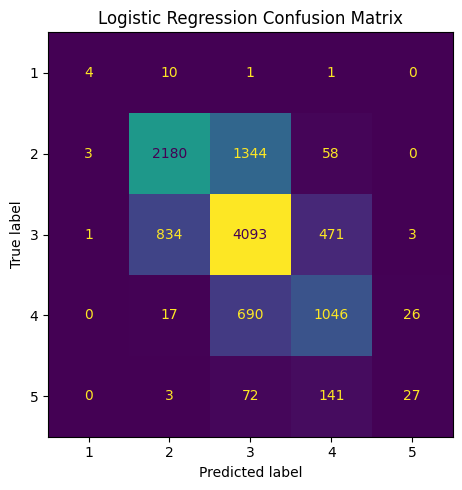

In [13]:
fig, ax = plt.subplots(figsize=(6,5))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logreg,
    ax=ax,
    colorbar=False
)


ax.set_title(
    "Logistic Regression Confusion Matrix"
)


plt.tight_layout()

plt.show()

## Classification Report

Precision, recall, and F1-score provide a better evaluation than accuracy alone because they show how well the model performs for each ESI class.

In [20]:
print(
    classification_report(
        y_test,
        pred_logreg,
        digits=3
    )
)

print(
    classification_report(
        y_test,
        pred_tree,
        digits=3
    )
)

              precision    recall  f1-score   support

           1      0.500     0.250     0.333        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.588     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.594     0.463     0.495     11025
weighted avg      0.666     0.667     0.661     11025

              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.796     0.265     0.398      3585
           3      0.527     0.959     0.680      5402
           4      0.000     0.000     0.000      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.556     11025
   macro avg      0.265     0.245     0.216     11025
weighted avg      0.517     0.556     0.463     11025



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Macro and Weighted F1 Score

Macro F1 gives equal importance to all ESI levels, while weighted F1 gives more importance to common classes.

Macro F1 is useful for evaluating imbalanced clinical datasets.

In [15]:
macro_f1 = f1_score(
    y_test,
    pred_logreg,
    average="macro"
)


weighted_f1 = f1_score(
    y_test,
    pred_logreg,
    average="weighted"
)


print("Macro F1:", round(macro_f1,3))

print("Weighted F1:", round(weighted_f1,3))

Macro F1: 0.495
Weighted F1: 0.661


## ESI Level 1 Recall

Recall for ESI level 1 measures how many of the most critically ill patients were correctly identified.

This is an important safety metric because false negatives for critical patients have serious consequences.

In [16]:
logreg_esi1_recall = recall_score(
    y_test,
    pred_logreg,
    labels=[1],
    average=None
)[0]


tree_esi1_recall = recall_score(
    y_test,
    pred_tree,
    labels=[1],
    average=None
)[0]


print(
    "Logistic Regression ESI-1 Recall:",
    round(logreg_esi1_recall,3)
)


print(
    "Decision Tree ESI-1 Recall:",
    round(tree_esi1_recall,3)
)

Logistic Regression ESI-1 Recall: 0.25
Decision Tree ESI-1 Recall: 0.0


## Model Comparison

The models are compared using accuracy, macro F1-score, and ESI level 1 recall.

In [17]:
def summarise(name, preds):

    return {
        "Model": name,
        "Accuracy": round(
            (preds == y_test).mean(),
            3
        ),
        "Macro F1": round(
            f1_score(
                y_test,
                preds,
                average="macro"
            ),
            3
        ),
        "ESI-1 Recall": round(
            recall_score(
                y_test,
                preds,
                labels=[1],
                average=None
            )[0],
            3
        )
    }


comparison = pd.DataFrame([
    summarise("Dummy Baseline", pred_dummy),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree", pred_tree)
])


comparison

,Model,Accuracy,Macro F1,ESI-1 Recall
0,Dummy Baseline,0.375,0.204,0.00
1,Logistic Regression,0.667,0.495,0.25
2,Decision Tree,0.556,0.216,0.00


## Save Confusion Matrix Figure

The confusion matrix is saved so it can be included in the project report or repository.

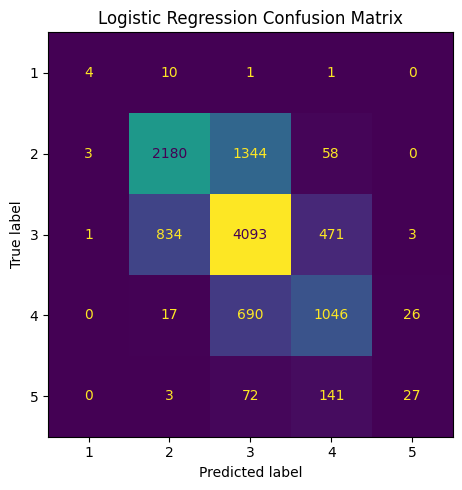

Figure saved.


In [18]:
os.makedirs("figs", exist_ok=True)


fig, ax = plt.subplots(figsize=(6,5))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logreg,
    ax=ax,
    colorbar=False
)


ax.set_title(
    "Logistic Regression Confusion Matrix"
)


plt.tight_layout()


plt.savefig(
    "figs/w6_confusion_logreg.png",
    dpi=110
)


plt.show()

print("Figure saved.")

# Exercise Answers

## 1. Decision Tree Confusion Matrix

The Decision Tree confusion matrix shows that the model commonly confuses neighbouring ESI levels, especially ESI 2 and ESI 3. This suggests the tree struggles to separate patients with similar levels of urgency.

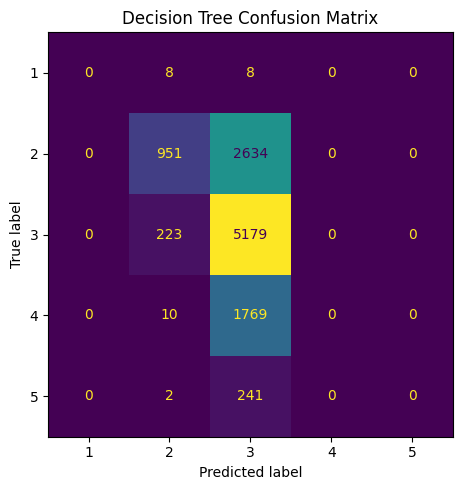

In [19]:
fig, ax = plt.subplots(figsize=(6,5))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_tree,
    ax=ax,
    colorbar=False
)


ax.set_title(
    "Decision Tree Confusion Matrix"
)


plt.tight_layout()

plt.savefig(
    "figs/w6_confusion_tree.png",
    dpi=110
)


plt.show()

## 2. Which model would you trust more?

Logistic Regression would be preferred because it achieved a higher macro F1 score and higher ESI-1 recall compared with the Decision Tree. This means it performed better across all classes and identified more critical patients.

## 3. Why is accuracy not enough?

Accuracy alone is not enough because a model can achieve a high score by predicting common classes while failing to identify rare but important cases such as ESI level 1 patients.